# Ambient AI Metric Notebook: ASR Demographic Word Error Parity (DWEP)

This notebook implements ASR Demographic Word Error Parity (DWEP) for the ambient clinical documentation use case.

**Goal:** Check whether ASR word error rate (WER) differs across demographic subgroups (e.g., race, dialect/accent, age cohort).

**Metric idea (DWEP):**
1. Compute WER per subgroup.
2. Compute disparity (for example, the max absolute WER gap between any two subgroups).
3. Compare disparity to a threshold (example: `max_gap ≤ 0.10`).

**Word Error Rate (WER) Definition per Subgroup**
WER = (S + D + I) / N
Where:

S = Substitutions

Words in the reference that were replaced with the wrong word by the ASR system.

D = Deletions

Words that appear in the reference transcript but are missing in the ASR output.

I = Insertions

Extra words added by the ASR system that were not present in the reference.

N = Number of words in the reference transcript


## What you need
A table where each row is an utterance (or segment) with:
- `reference_text`: ground-truth transcript
- `hypothesis_text`: ASR output
- subgroup columns (e.g., `race`, `accent`, `age_group`)

This notebook includes:
- A clean WER implementation (no external dependency)
- Grouped WER + disparity report
- A simple pass/fail check for DWEP


## 1) Setup

In [ ]:
# Standard library helpers for text cleanup and subgroup comparisons
import re
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

# Core data tooling
import numpy as np
import pandas as pd

## 2) Text normalization

Ambient audio can include fillers, punctuation, and casing differences. You should normalize consistently before scoring.

Below is a simple normalizer:
- lowercase
- strip punctuation (keeps apostrophes inside words)
- collapse whitespace


In [2]:
# Normalize text so casing and punctuation do not inflate WER
def normalize_text(text: str) -> str:
    if (text is None):
        return ""
    text = text.lower()
    # Keep letters, numbers, apostrophes, and spaces
    text = re.sub(r"[^a-z0-9'\s]+", " ", text)
    # Collapse repeated whitespace after cleanup
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Split normalized text into word tokens for alignment
def tokenize_words(text: str) -> List[str]:
    text = normalize_text(text)
    if (text == ""):
        return []
    return text.split(" ")

## 3) Word Error Rate (WER)

We compute word-level Levenshtein alignment to count:
- substitutions (S)
- deletions (D)
- insertions (I)

Then:  \( {WER} = (S + D + I) / N \), where \(N\) is the number of reference words.


In [3]:
@dataclass
class WerCounts:
    # Store edit counts plus the reference length for WER
    S: int
    D: int
    I: int
    N: int  # number of reference words

    @property
    def wer(self) -> float:
        if (self.N == 0):
            # Handle empty-reference edge cases without dividing by zero
            return 0.0 if ((self.S + self.D + self.I) == 0) else 1.0
        return (self.S + self.D + self.I) / self.N


# Compute word-level edit counts between a reference and a hypothesis
def wer_counts(reference: str, hypothesis: str) -> WerCounts:
    ref = tokenize_words(reference)
    hyp = tokenize_words(hypothesis)

    n = len(ref)
    m = len(hyp)

    # Initialize the edit-distance table and backtrace map
    dp = np.zeros((n + 1, m + 1), dtype=int)
    back = np.empty((n + 1, m + 1), dtype=object)

    # Seed the first column as deletions from the reference
    for i in range(n + 1):
        dp[i, 0] = i
        back[i, 0] = 'D' if (i > 0) else None

    # Seed the first row as insertions into the hypothesis
    for j in range(m + 1):
        dp[0, j] = j
        back[0, j] = 'I' if (j > 0) else None

    # Fill the dynamic-programming table one token pair at a time
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if (ref[i - 1] == hyp[j - 1]) else 1

            sub = dp[i - 1, j - 1] + cost
            dele = dp[i - 1, j] + 1
            ins = dp[i, j - 1] + 1

            best = min(sub, dele, ins)
            dp[i, j] = best

            if (best == sub):
                back[i, j] = 'E' if (cost == 0) else 'S'
            elif (best == dele):
                back[i, j] = 'D'
            else:
                back[i, j] = 'I'

    # Walk backward through the table to recover operation counts
    i, j = n, m
    S = D = I = 0

    while ((i > 0) or (j > 0)):
        op = back[i, j]
        if (op == 'E'):
            i -= 1
            j -= 1
        elif (op == 'S'):
            S += 1
            i -= 1
            j -= 1
        elif (op == 'D'):
            D += 1
            i -= 1
        elif (op == 'I'):
            I += 1
            j -= 1
        else:
            # Safety guard for unexpected backtrace states
            break

    return WerCounts(S=S, D=D, I=I, N=len(ref))

## 4) Example dataset (synthetic)

Replace this with your real evaluation set.


In [4]:
# Small synthetic sample for the demo
df = pd.DataFrame(
    [
        # Race groups
        {
            "utterance_id": "u1",
            "race": "Black",
            "accent": "US_native",
            "age_group": "adult",
            "reference_text": "patient denies chest pain and is taking advil",
            "hypothesis_text": "patient denies chest pain and is taking a bill",
        },
        {
            "utterance_id": "u2",
            "race": "Black",
            "accent": "US_native",
            "age_group": "adult",
            "reference_text": "blood pressure is elevated start lisinopril",
            "hypothesis_text": "blood pressure is elevated start lisinopril",
        },
        {
            "utterance_id": "u3",
            "race": "White",
            "accent": "US_native",
            "age_group": "adult",
            "reference_text": "schedule a follow up in two weeks for back pain",
            "hypothesis_text": "schedule a follow up in two weeks for back pain",
        },
        {
            "utterance_id": "u4",
            "race": "White",
            "accent": "US_native",
            "age_group": "adult",
            "reference_text": "patient reports nausea after taking metformin",
            "hypothesis_text": "patient reports nausea after taking met formin",
        },
        # Accent groups
        {
            "utterance_id": "u5",
            "race": "Black",
            "accent": "non_native",
            "age_group": "adult",
            "reference_text": "no fever no chills and no shortness of breath",
            "hypothesis_text": "no fever no chills and no shortness of breath",
        },
        {
            "utterance_id": "u6",
            "race": "White",
            "accent": "non_native",
            "age_group": "adult",
            "reference_text": "patient has chronic kidney disease stage three",
            "hypothesis_text": "patient has chronic kidney disease stage tree",
        },
    ]
)

# Quick look at the sample input
df

,utterance_id,race,accent,age_group,reference_text,hypothesis_text
0,u1,Black,US_native,adult,patient denies chest pain and is taking advil,patient denies chest pain and is taking a bill
1,u2,Black,US_native,adult,blood pressure is elevated start lisinopril,blood pressure is elevated start lisinopril
2,u3,White,US_native,adult,schedule a follow up in two weeks for back pain,schedule a follow up in two weeks for back pain
3,u4,White,US_native,adult,patient reports nausea after taking metformin,patient reports nausea after taking met formin
4,u5,Black,non_native,adult,no fever no chills and no shortness of breath,no fever no chills and no shortness of breath
5,u6,White,non_native,adult,patient has chronic kidney disease stage three,patient has chronic kidney disease stage tree


## 5) Compute WER per utterance

In [5]:
# Score each utterance and append the edit counts to the original frame
def add_wer_columns(df: pd.DataFrame,
                    ref_col: str = "reference_text",
                    hyp_col: str = "hypothesis_text") -> pd.DataFrame:
    out = df.copy()

    # Run WER once per row so the counts stay aligned with the input data
    counts = [wer_counts(r, h) for r, h in zip(out[ref_col], out[hyp_col])]
    out["S"] = [c.S for c in counts]
    out["D"] = [c.D for c in counts]
    out["I"] = [c.I for c in counts]
    out["N"] = [c.N for c in counts]
    out["WER"] = [c.wer for c in counts]
    return out


df_scored = add_wer_columns(df)
# Review utterance-level scores
df_scored

,utterance_id,race,accent,age_group,reference_text,hypothesis_text,S,D,I,N,WER
0,u1,Black,US_native,adult,patient denies chest pain and is taking advil,patient denies chest pain and is taking a bill,1,0,1,8,0.250000
1,u2,Black,US_native,adult,blood pressure is elevated start lisinopril,blood pressure is elevated start lisinopril,0,0,0,6,0.000000
2,u3,White,US_native,adult,schedule a follow up in two weeks for back pain,schedule a follow up in two weeks for back pain,0,0,0,10,0.000000
3,u4,White,US_native,adult,patient reports nausea after taking metformin,patient reports nausea after taking met formin,1,0,1,6,0.333333
4,u5,Black,non_native,adult,no fever no chills and no shortness of breath,no fever no chills and no shortness of breath,0,0,0,9,0.000000
5,u6,White,non_native,adult,patient has chronic kidney disease stage three,patient has chronic kidney disease stage tree,1,0,0,7,0.142857


## 6) DWEP report for a subgroup column

For a chosen subgroup column (e.g., `race`), we compute:
- total counts per group (S, D, I, N)
- group WER
- max absolute WER gap across any two groups (the disparity used by DWEP)

You can run this for multiple subgroup columns.


In [6]:
# Aggregate WER by subgroup and flag the largest disparity
def dwep_report(df_scored: pd.DataFrame,
                subgroup_col: str,
                wer_gap_threshold: float = 0.10) -> Dict[str, object]:
    if (subgroup_col not in df_scored.columns):
        raise ValueError(f"Missing subgroup_col: {subgroup_col}")

    # Roll up edit counts at the subgroup level
    grouped = df_scored.groupby(subgroup_col, dropna=False).agg(
        utterances=("utterance_id", "count"),
        S=("S", "sum"),
        D=("D", "sum"),
        I=("I", "sum"),
        N=("N", "sum"),
    ).reset_index()

    # Recompute WER from the aggregated counts
    grouped["WER"] = (grouped["S"] + grouped["D"] + grouped["I"]) / grouped["N"].replace(0, np.nan)
    grouped["WER"] = grouped["WER"].fillna(0.0)

    # Compare every subgroup pair to find the largest gap
    gaps = []
    for (a, b) in combinations(grouped[subgroup_col].tolist(), 2):
        wer_a = float(grouped.loc[grouped[subgroup_col] == a, "WER"].iloc[0])
        wer_b = float(grouped.loc[grouped[subgroup_col] == b, "WER"].iloc[0])
        gaps.append({"group_a": a, "group_b": b, "abs_gap": abs(wer_a - wer_b)})

    # Build a tidy pairwise gap table
    gaps_df = pd.DataFrame(gaps).sort_values("abs_gap", ascending=False) if (len(gaps) > 0) else pd.DataFrame(
        columns=["group_a", "group_b", "abs_gap"]
    )

    max_gap = float(gaps_df["abs_gap"].max()) if (len(gaps_df) > 0) else 0.0
    passes = (max_gap <= wer_gap_threshold)

    return {
        "subgroup_col": subgroup_col,
        "threshold": wer_gap_threshold,
        "max_abs_gap": max_gap,
        "passes": passes,
        "group_table": grouped.sort_values("WER", ascending=False),
        "pairwise_gaps": gaps_df,
    }


report_race = dwep_report(df_scored, subgroup_col="race", wer_gap_threshold=0.10)
# Inspect subgroup-level results for race
report_race["group_table"]

,race,utterances,S,D,I,N,WER
1,White,3,2,0,1,23,0.130435
0,Black,3,1,0,1,23,0.086957


### Pairwise gaps (race)

In [7]:
# Show the pairwise race gaps from largest to smallest
report_race["pairwise_gaps"]

,group_a,group_b,abs_gap
0,Black,White,0.043478


## 7) Pass/fail decision (race)

If `max_abs_gap ≤ 0.10`, DWEP passes for this subgroup definition.


In [8]:
# Return the pass flag, observed max gap, and configured threshold
report_race["passes"], report_race["max_abs_gap"], report_race["threshold"]

(True, 0.043478260869565216, 0.1)

## 8) Run DWEP across multiple subgroup columns

In ambient documentation, you often care about:
- race/ethnicity
- native vs non-native accent
- age cohort
- gender (if available and appropriate)
- language/dialect

Below is a helper that runs the report for each subgroup column and returns a compact summary.


In [9]:
# Run the same disparity check across several subgroup definitions
def dwep_multi(df_scored: pd.DataFrame,
              subgroup_cols: List[str],
              wer_gap_threshold: float = 0.10) -> Tuple[pd.DataFrame, Dict[str, Dict[str, object]]]:
    reports = {}
    rows = []

    for col in subgroup_cols:
        # Keep the full report and a one-row summary for each subgroup
        rep = dwep_report(df_scored, subgroup_col=col, wer_gap_threshold=wer_gap_threshold)
        reports[col] = rep
        rows.append(
            {
                "subgroup_col": col,
                "max_abs_gap": rep["max_abs_gap"],
                "threshold": rep["threshold"],
                "passes": rep["passes"],
                "num_groups": rep["group_table"].shape[0],
            }
        )

    return pd.DataFrame(rows).sort_values("max_abs_gap", ascending=False), reports


summary, reports = dwep_multi(df_scored, subgroup_cols=["race", "accent", "age_group"], wer_gap_threshold=0.10)
# Compare subgroup results side by side
summary

,subgroup_col,max_abs_gap,threshold,passes,num_groups
1,accent,0.070833,0.1,True,2
0,race,0.043478,0.1,True,2
2,age_group,0.000000,0.1,True,1


## 9) Optional: quick visualization

A bar chart of group WER can make disparities obvious.


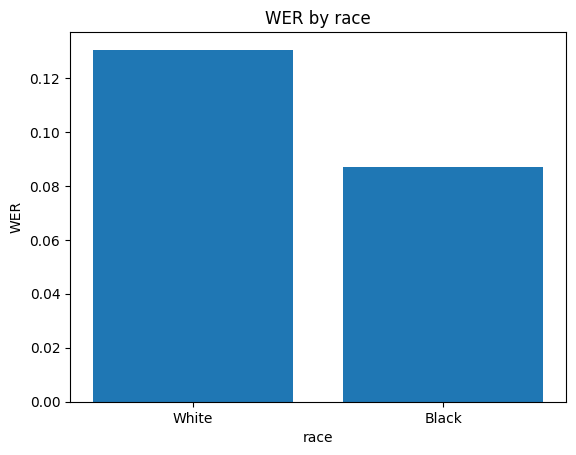

In [10]:
# Plotting for the optional visual check
import matplotlib.pyplot as plt

# Quick bar chart for subgroup WER values
def plot_group_wer(group_table: pd.DataFrame, subgroup_col: str):
    plt.figure()
    x = group_table[subgroup_col].astype(str).tolist()
    y = group_table["WER"].tolist()
    plt.bar(x, y)
    plt.xlabel(subgroup_col)
    plt.ylabel("WER")
    plt.title(f"WER by {subgroup_col}")
    plt.show()


plot_group_wer(reports["race"]["group_table"], "race")

## 10) Notes for real-world ambient AI evaluation

**Segmenting audio**
- Use consistent segmentation (per utterance, per speaker turn, or fixed time windows).
- If possible, separate clinician vs patient speech and score both.

**Demographic labels**
- Use the subgroup definition that matches your fairness question.
- For sensitive attributes, follow IRB and privacy constraints.

**Interpreting DWEP**
- If DWEP fails, inspect:
  - Which words drive errors (medical terms, names, drug names)
  - Which acoustic conditions correlate (masking, room noise, mic distance)
  - Whether the issue is concentrated in patient speech

**Extension ideas**
- Confidence intervals via bootstrap per subgroup
- Stratify by setting (ED vs outpatient) and device type
- Add a second metric for clinical term capture (medical term recall) so errors are clinically meaningful, not just WER
